# Lab 09 · Reading scanned work orders

**Day 3 · S16, lab 2 of 3** · Budget: 20 min of the 25 min slot · Runs on: Colab with a T4 GPU (a laptop works, slower)

A vision model reads maintenance work orders and fills in a JSON record: IDs, dates, ticked boxes, and a table of readings. It's the same two models as lab 08: self-hosted (Ollama on the Colab runtime, standing in for OQ's own VM) and a vendor API.

This lab is about one failure in particular: **a model that fills in a blank field with a plausible value.**

| Tier | Images | What it tests |
|---|---|---|
| 1 | wo_01 to wo_03 | clean digital form |
| 2 | wo_04 to wo_06 | the same three forms, office scan |
| 3 | wo_07 to wo_09 | the same three forms, faxed, with a RECEIVED stamp over one field |
| known-bad | wo_10 | clean, but three fields were left blank |

## 1. Setup

On a fresh Colab runtime the next two cells install Ollama and download the self-hosted model, which takes about 3 minutes. Start them now and read ahead while they run.

The vendor model needs an `OPENAI_API_KEY`: in Colab, add it under **Secrets** (the key icon on the left); on a laptop, put it in a `.env` file in the lab folder. If a model isn't available the lab carries on with the other one, or with the facilitator's saved outputs.

In [4]:
# Setup: find the lab folder, detect the runtime, install pinned packages on Colab.
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = os.environ.get("LAB_REPO_URL", "")  # Colab: the course repo URL, once it is published


def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "vision_client.py").exists():
            return p


ROOT = find_root()
if ROOT is None and IN_COLAB and REPO_URL:
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/lab"], check=True)
    ROOT = Path("/content/lab")
if ROOT is None:
    raise RuntimeError("Lab folder not found. Open this notebook from inside it, or set LAB_REPO_URL on Colab.")
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "openai==3.0.0", "python-dotenv==1.1.0"], check=True)
sys.path.insert(0, str(ROOT / "scripts"))
print("lab folder:", ROOT, "| runtime:", "Colab" if IN_COLAB else "local")

lab folder: /Users/drpreetyrai./aiguru | runtime: local


In [5]:
from vision_client import ensure_ollama, load_openai_key, prebaked_models, run_batch, self_hosted, vendor_api

RUN_MODE = os.environ.get("LAB_RUN_MODE", "live")  # "live" calls the models, "prebaked" replays a saved run
LAB = "09"
OUT = ROOT / "outputs" / LAB
PREBAKED = Path(os.environ.get("LAB_PREBAKED_DIR", ROOT / "facilitator" / "prebaked_outputs")) / LAB

MODELS = []
if RUN_MODE == "live":
    try:
        ensure_ollama()
        MODELS.append(self_hosted())
    except Exception as e:
        print("self-hosted model unavailable:", e)
    if load_openai_key(ROOT):
        MODELS.append(vendor_api())
    else:
        print("vendor API unavailable: no OPENAI_API_KEY in Colab secrets or .env")
if not MODELS:
    MODELS = prebaked_models(PREBAKED)
    print("using prebaked outputs from", PREBAKED)
assert MODELS, f"No live model and no prebaked outputs in {PREBAKED}. Ask the facilitator."
print("models:", [m.label for m in MODELS])

self-hosted model unavailable: Ollama is not installed. See setup/ollama_setup.md or https://ollama.com/download
models: ['vendor API: gpt-4.1-mini']


## 2. Look at the images

In [6]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from render_images import build_image_set

MANIFEST = ROOT / "corpus" / "images" / "manifest.csv"
TRUTH = ROOT / "data" / "eval" / "image_ground_truth"
if not MANIFEST.exists():
    build_image_set(ROOT)
manifest = pd.read_csv(MANIFEST)
items = manifest[manifest.kind == "form"]


def show(item_ids, height=4.5):
    fig, axes = plt.subplots(1, len(item_ids), figsize=(6.5 * len(item_ids), height))
    for ax, item_id in zip(np.atleast_1d(axes), item_ids):
        ax.imshow(Image.open(ROOT / "corpus" / "images" / f"{item_id}.png"))
        ax.set_title(item_id)
        ax.axis("off")
    plt.show()


def truth(item_id):
    return json.loads((TRUTH / f"{item_id}.json").read_text())


items[["item_id", "tier", "degradation", "source", "known_bad"]]

,item_id,tier,degradation,source,known_bad
10,wo_01,1,clean,record_A,False
11,wo_02,1,clean,record_B,False
12,wo_03,1,clean,record_C,False
13,wo_04,2,scan,record_A,False
14,wo_05,2,scan,record_B,False
15,wo_06,2,scan,record_C,False
16,wo_07,3,fax,record_A,False
17,wo_08,3,fax,record_B,False
18,wo_09,3,fax,record_C,False
19,wo_10,known-bad,clean,record_KB,True


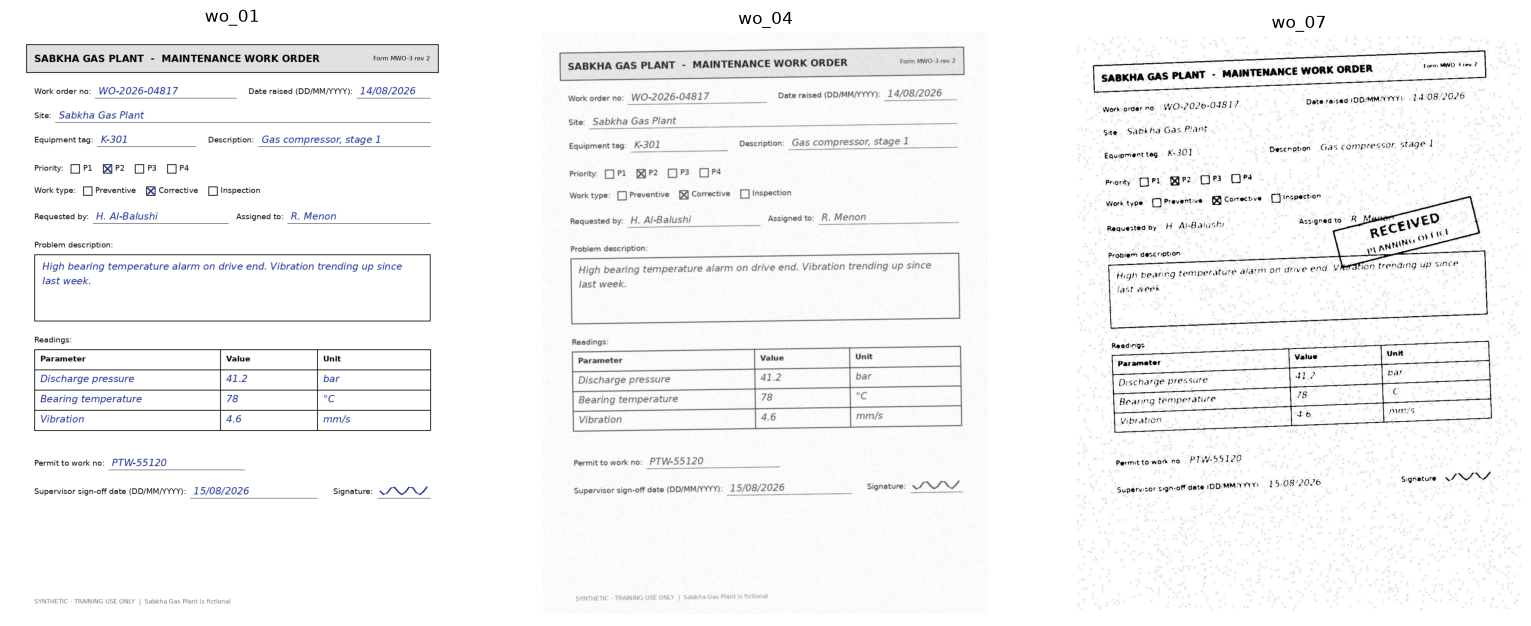

In [7]:
show(["wo_01", "wo_04", "wo_07"], height=9)

The same work order at three qualities. On the fax, check the decimal points in the readings table and the name under the stamp.

Here's the known-bad form. Find the three blank fields.

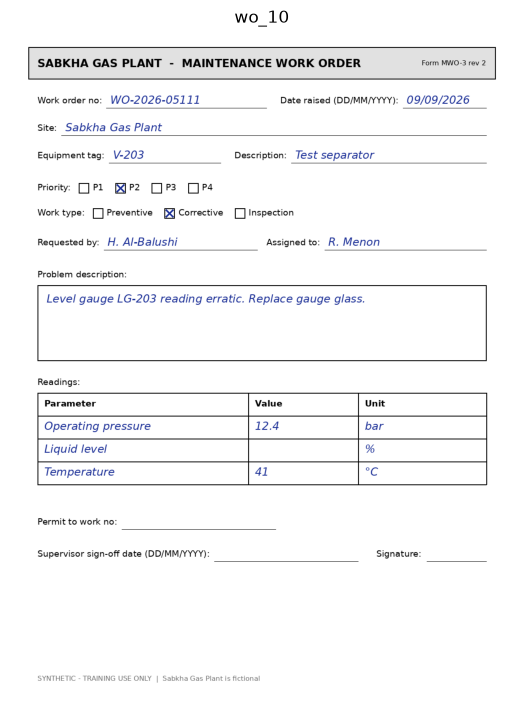

In [8]:
show(["wo_10"], height=9)

## 3. The extraction contract

Every field in the schema can be `null`, and the prompt says to use `null` for anything blank. Watch whether the models do it.

In [9]:
S = {"type": ["string", "null"]}
FORM_SCHEMA = {
    "type": "object",
    "properties": {
        "work_order_id": S,
        "date_raised": S,
        "site": S,
        "equipment_tag": S,
        "equipment_description": S,
        "priority": {"type": ["string", "null"], "enum": ["P1", "P2", "P3", "P4", None]},
        "work_type": {"type": ["string", "null"], "enum": ["Preventive", "Corrective", "Inspection", None]},
        "requested_by": S,
        "assigned_to": S,
        "problem_description": S,
        "readings": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {"parameter": {"type": "string"}, "value": {"type": ["number", "null"]}, "unit": S},
                "required": ["parameter", "value", "unit"],
                "additionalProperties": False,
            },
        },
        "permit_number": S,
        "supervisor_signoff_date": S,
    },
    "additionalProperties": False,
}
FORM_SCHEMA["required"] = list(FORM_SCHEMA["properties"])

PROMPT = """You are reading a scanned maintenance work order form. Fill in the JSON fields from it.
- Copy text exactly as written.
- Dates are written DD/MM/YYYY on the form. Return them as YYYY-MM-DD.
- For priority and work type, return the option whose box is ticked.
- Readings: one entry per table row. The value is the number only.
- If a field or a table cell is empty, return null. Never guess a value that is not written on the form."""

## 4. All ten forms, both models

Results are cached in `outputs/09/<model>/`, so running this again after the break costs nothing.

In [10]:
jobs = [{"item_id": r.item_id, "image": ROOT / r.image} for r in items.itertuples()]
for vm in MODELS:
    run_batch(vm, jobs, prompt=PROMPT, schema=FORM_SCHEMA, out_dir=OUT, prebaked_dir=PREBAKED,
              workers=4 if vm.backend == "openai" else 1)

first = json.loads((OUT / MODELS[0].name / "wo_01.json").read_text())["output"]
print(json.dumps(first, indent=2, ensure_ascii=False))

  wo_01: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked  wo_02: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked
  wo_04: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked

  wo_03: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked
  wo_05: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked
  wo_06: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked
  wo_07: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked
  wo_08: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked


## 5. Score

There are 18 scored fields per form: 12 single fields, plus a value and a unit for each of the three readings. Case, spacing and punctuation don't count as errors, so `R Menon` matches `R. Menon`. Dates must come back as `YYYY-MM-DD`.

**hallucinated** counts fields that are blank on the form but got a value. **missed** counts fields that are filled in on the form but came back null.

In [11]:
from score_extraction import score_dir, summary

scores = score_dir(OUT, TRUTH, manifest, "form")
summary(scores)

label,vendor API: gpt-4.1-mini
tier,
1,1.000
2,0.981
3,0.852
known-bad,1.000


In [12]:
scores[["item_id", "tier", "label", "score", "correct", "hallucinated", "missed", "seconds"]]

,item_id,tier,label,score,correct,hallucinated,missed,seconds
0,wo_01,1,vendor API: gpt-4.1-mini,1.000,18,0,0,4.44
1,wo_02,1,vendor API: gpt-4.1-mini,1.000,18,0,0,4.19
2,wo_03,1,vendor API: gpt-4.1-mini,1.000,18,0,0,5.53
3,wo_04,2,vendor API: gpt-4.1-mini,0.944,17,0,0,7.64
4,wo_05,2,vendor API: gpt-4.1-mini,1.000,18,0,0,5.33
5,wo_06,2,vendor API: gpt-4.1-mini,1.000,18,0,0,4.89
6,wo_07,3,vendor API: gpt-4.1-mini,0.778,14,0,0,4.16
7,wo_08,3,vendor API: gpt-4.1-mini,0.833,15,0,0,3.96
8,wo_09,3,vendor API: gpt-4.1-mini,0.944,17,0,0,4.38
9,wo_10,known-bad,vendor API: gpt-4.1-mini,1.000,18,0,0,4.62


### Which fields break first?

This is the fraction of extractions that got each field right, with both models pooled. As the scan gets worse, look at the ticked boxes (priority, work type), the readings, and `assigned_to`, which sits under the stamp on the fax.

In [13]:
field_table = pd.DataFrame([{"tier": r.tier, **r.field_ok} for r in scores.itertuples()])
field_table.groupby("tier").mean().T.round(2)

tier,1,2,3,known-bad
work_order_id,1.0,1.00,0.33,1.0
date_raised,1.0,1.00,1.00,1.0
site,1.0,1.00,0.67,1.0
equipment_tag,1.0,1.00,1.00,1.0
equipment_description,1.0,1.00,1.00,1.0
priority,1.0,1.00,1.00,1.0
work_type,1.0,1.00,1.00,1.0
requested_by,1.0,1.00,0.67,1.0
assigned_to,1.0,1.00,0.67,1.0
problem_description,1.0,1.00,1.00,1.0


## 6. The known-bad case

On wo_10 the permit number, the supervisor sign-off date and the liquid level are all blank. The right answer for each is `null`. Anything else was invented.

In [14]:
for r in scores[scores.known_bad].itertuples():
    print(f"{r.label}: {r.hallucinated} invented value(s), score {r.score}")
    for e in r.errors:
        print("   ", e)

vendor API: gpt-4.1-mini: 0 invented value(s), score 1.0


## 7. Would validation have caught it?

These are the rules a developer would write anyway: format checks, date logic, and one business rule (hands-on work needs a permit). Any flag sends the record to a person instead of straight into the ERP.

In [15]:
import re
from datetime import date


def validate(rec: dict) -> list[str]:
    """Flags for a person to check. An empty list means the record goes straight through."""
    flags = []
    patterns = {"work_order_id": r"WO-\d{4}-\d{5}", "equipment_tag": r"[A-Z]{1,3}-\d{3}[A-Z]?",
                "permit_number": r"PTW-\d{5}"}
    for field, pattern in patterns.items():
        value = rec.get(field)
        if value and not re.fullmatch(pattern, value):
            flags.append(f"{field} format: {value!r}")
    dates = {}
    for field in ("date_raised", "supervisor_signoff_date"):
        if rec.get(field):
            try:
                dates[field] = date.fromisoformat(rec[field])
            except ValueError:
                flags.append(f"{field} is not YYYY-MM-DD: {rec[field]!r}")
    if len(dates) == 2 and dates["supervisor_signoff_date"] < dates["date_raised"]:
        flags.append("signed off before it was raised")
    if rec.get("work_type") in ("Corrective", "Preventive") and not rec.get("permit_number"):
        flags.append("hands-on work with no permit number")
    for r in rec.get("readings") or []:
        if r.get("value") is None:
            flags.append(f"reading missing: {r.get('parameter')}")
    return flags


def load_pred(model, item_id):
    path = OUT / model / f"{item_id}.json"
    return json.loads(path.read_text())["output"] if path.exists() else None


check = scores[["item_id", "tier", "label", "model", "fields", "correct", "hallucinated"]].copy()
check["flags"] = [validate(load_pred(m, i) or {}) for m, i in zip(check.model, check.item_id)]
check["wrong_fields"] = check.fields - check.correct
check["sent_to_person"] = check["flags"].str.len() > 0

wrong = check[check.wrong_fields > 0]
print(f"{len(wrong)} of {len(check)} extractions have at least one wrong field; "
      f"the rules sent {wrong.sent_to_person.sum()} of those to a person.")
check[["item_id", "tier", "label", "wrong_fields", "hallucinated", "sent_to_person", "flags"]]

4 of 10 extractions have at least one wrong field; the rules sent 0 of those to a person.


,item_id,tier,label,wrong_fields,hallucinated,sent_to_person,flags
0,wo_01,1,vendor API: gpt-4.1-mini,0,0,False,[]
1,wo_02,1,vendor API: gpt-4.1-mini,0,0,False,[]
2,wo_03,1,vendor API: gpt-4.1-mini,0,0,False,[]
3,wo_04,2,vendor API: gpt-4.1-mini,1,0,False,[]
4,wo_05,2,vendor API: gpt-4.1-mini,0,0,False,[]
5,wo_06,2,vendor API: gpt-4.1-mini,0,0,False,[]
6,wo_07,3,vendor API: gpt-4.1-mini,4,0,False,[]
7,wo_08,3,vendor API: gpt-4.1-mini,3,0,False,[]
8,wo_09,3,vendor API: gpt-4.1-mini,1,0,False,[]
9,wo_10,known-bad,vendor API: gpt-4.1-mini,0,0,True,"[hands-on work with no permit number, reading ..."


Rules catch values with the wrong shape: a date that isn't `YYYY-MM-DD`, a tag with the wrong pattern. They can't catch a value that is well formed but wrong. An invented `PTW-55xxx` passes every regex.

Look at wo_10. If a model correctly returns `null`, the rules flag "no permit number" and a person checks it, which is the right outcome. If a model invents a permit number, the record goes straight through. **A blank that stays blank is safer than a guess.**

## 8. Try it: ask about one field at a time (if you have time)

A narrow question about a single field is harder to answer by pattern-matching than a whole form. This asks each model about the two risky fields on a filled-in form (wo_01) and on the blank one (wo_10).

In [16]:
CHECK_PROMPT = """Look only at the field labelled "{label}" on this form.
If nothing is written in it, answer exactly: EMPTY
Otherwise answer with exactly the text written in it, and nothing else."""
CHECKS = {"permit_number": "Permit to work no", "supervisor_signoff_date": "Supervisor sign-off date (DD/MM/YYYY)"}

TRY_OUT, TRY_PREBAKED = ROOT / "outputs" / "09_try", PREBAKED.parent / "09_try"
check_jobs = [{"item_id": f"{item}_{field}", "item": item, "field": field,
               "image": ROOT / f"corpus/images/{item}.png", "prompt": CHECK_PROMPT.format(label=label)}
              for item in ("wo_01", "wo_10") for field, label in CHECKS.items()]
rows = []
for vm in MODELS:
    results = run_batch(vm, check_jobs, out_dir=TRY_OUT, prebaked_dir=TRY_PREBAKED, verbose=False)
    for job, rec in zip(check_jobs, results):
        rows.append({"item": job["item"], "field": job["field"], "model": rec["label"],
                     "answer": rec["output"] or rec["error"], "truth": truth(job["item"])[job["field"]] or "EMPTY"})
pd.DataFrame(rows)

  wo_01_permit_number: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked
  wo_01_supervisor_signoff_date: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked
  wo_10_permit_number: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked
  wo_10_supervisor_signoff_date: live call failed (TypeError: Invalid `http_client` argument; Expected an instance of `httpx.Client), using prebaked


,item,field,model,answer,truth
0,wo_01,permit_number,vendor API: gpt-4.1-mini,PTW-55120,PTW-55120
1,wo_01,supervisor_signoff_date,vendor API: gpt-4.1-mini,15/08/2026,2026-08-15
2,wo_10,permit_number,vendor API: gpt-4.1-mini,EMPTY,EMPTY
3,wo_10,supervisor_signoff_date,vendor API: gpt-4.1-mini,EMPTY,EMPTY


## 9. What to take away

- **Scans fail on the small things first:** decimal points, ticked boxes, text under a stamp.
- **The most dangerous error is an invented value in a blank field.** It's well formed and plausible, so it passes validation.
- **Make "blank" a real answer.** Allow `null` in the schema, tell the model to use it, and send nulls in required fields to a person.
- **Asking about one field at a time is slower, but more careful.** Use it for the few fields that carry risk, such as permits and sign-offs.

## Facilitator: save this run as the room's fallback

In [17]:
from vision_client import promote_to_prebaked

PROMOTE = False  # facilitator only: after a good live run, keep it for when the network or a model fails
if PROMOTE and RUN_MODE == "live":
    promote_to_prebaked(OUT, PREBAKED)
    promote_to_prebaked(TRY_OUT, TRY_PREBAKED)    